In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


## 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
print(f"Shape: {df.shape}")

Shape: (2640, 12)


## 3. Basic Exploration (EDA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
print("Missing Values: \n", df.isnull().sum())

Missing Values: 
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [8]:
print("Checking duplicates:")
df.duplicated().sum()

Checking duplicates:


np.int64(0)

#### Hence, we see that there are 0 missing values and 0 duplicates which means the dataset is clean & structurally complete.

In [9]:
df['Region'].value_counts()

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

In [10]:
df['Model'].value_counts()

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

## 4. Univariate Analysis

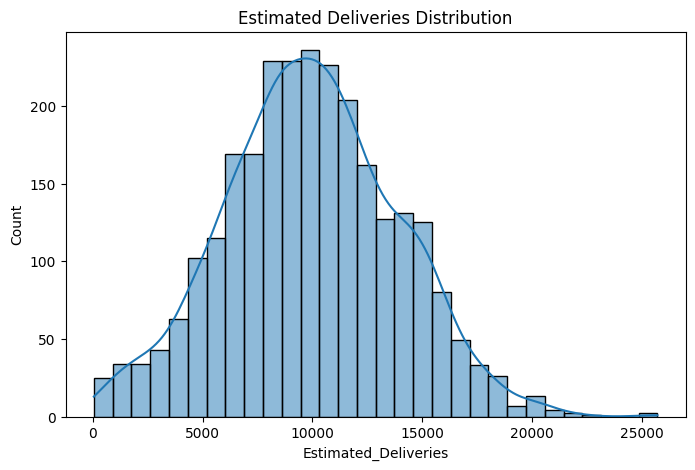

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)

plt.title("Estimated Deliveries Distribution")
plt.show()

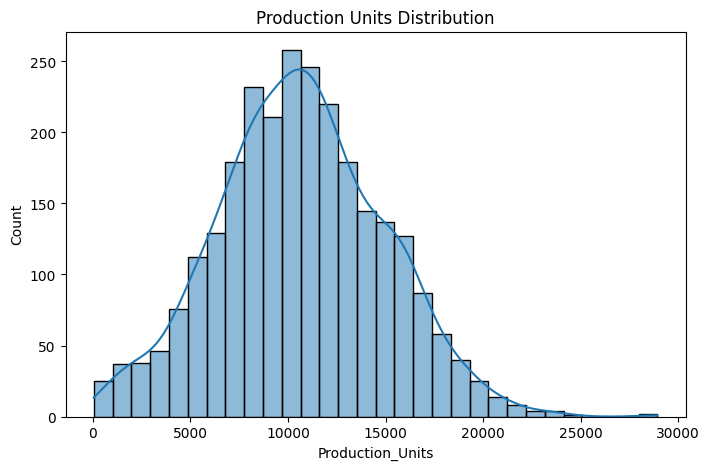

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Production_Units"], bins=30, kde=True)
plt.title("Production Units Distribution")

plt.show()

## 5. Categorical columns analysis

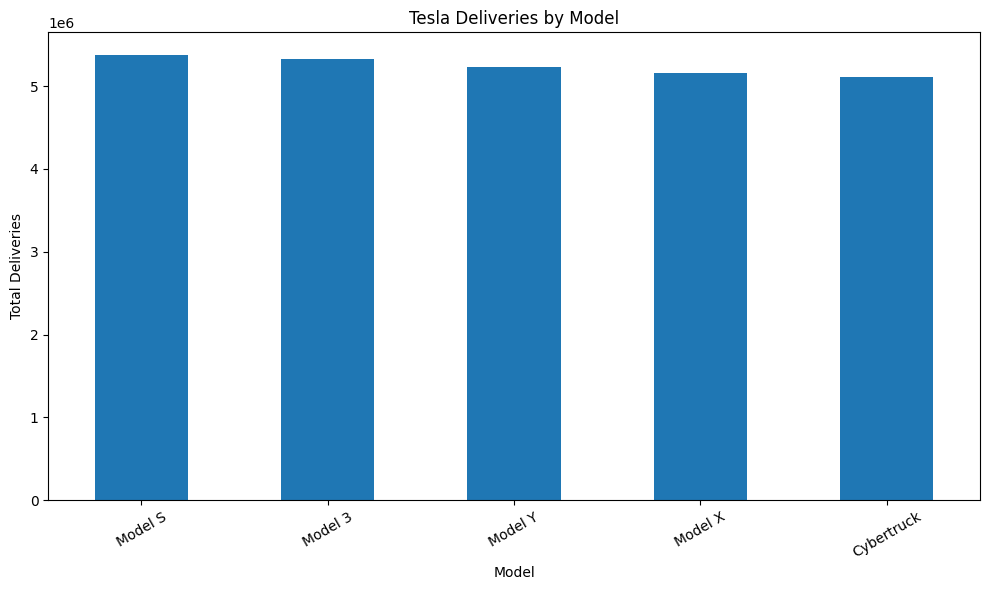

In [13]:
model_deliveries = (df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False))

plt.figure(figsize=(10,6))

model_deliveries.plot(kind="bar")

plt.title("Tesla Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Deliveries")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

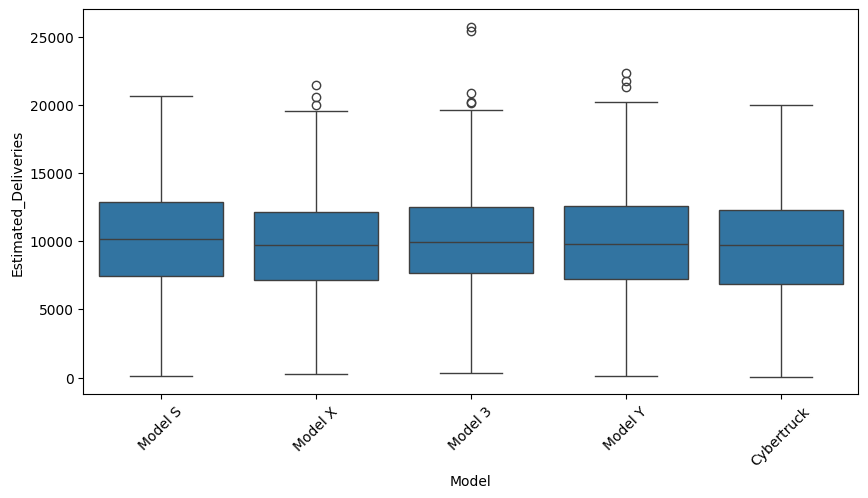

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Model", y="Estimated_Deliveries", data=df)

plt.xticks(rotation=45)

plt.show()

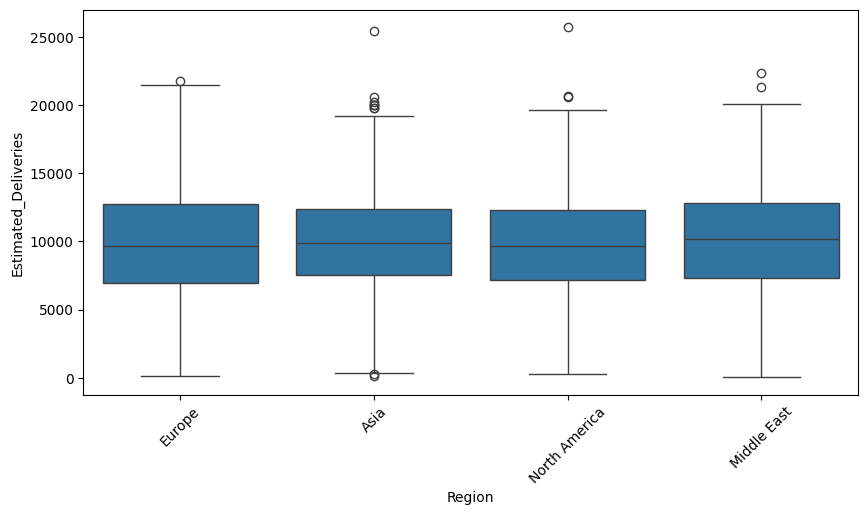

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Region", y="Estimated_Deliveries", data=df)

plt.xticks(rotation=45)

plt.show()

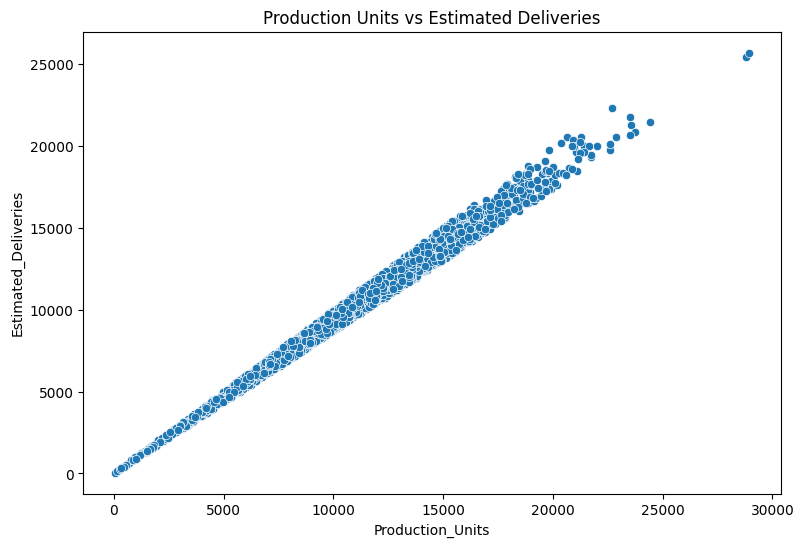

In [16]:
plt.figure(figsize=(9,6))

sns.scatterplot(x = 'Production_Units', y = 'Estimated_Deliveries', data = df)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

## 6. Correlation

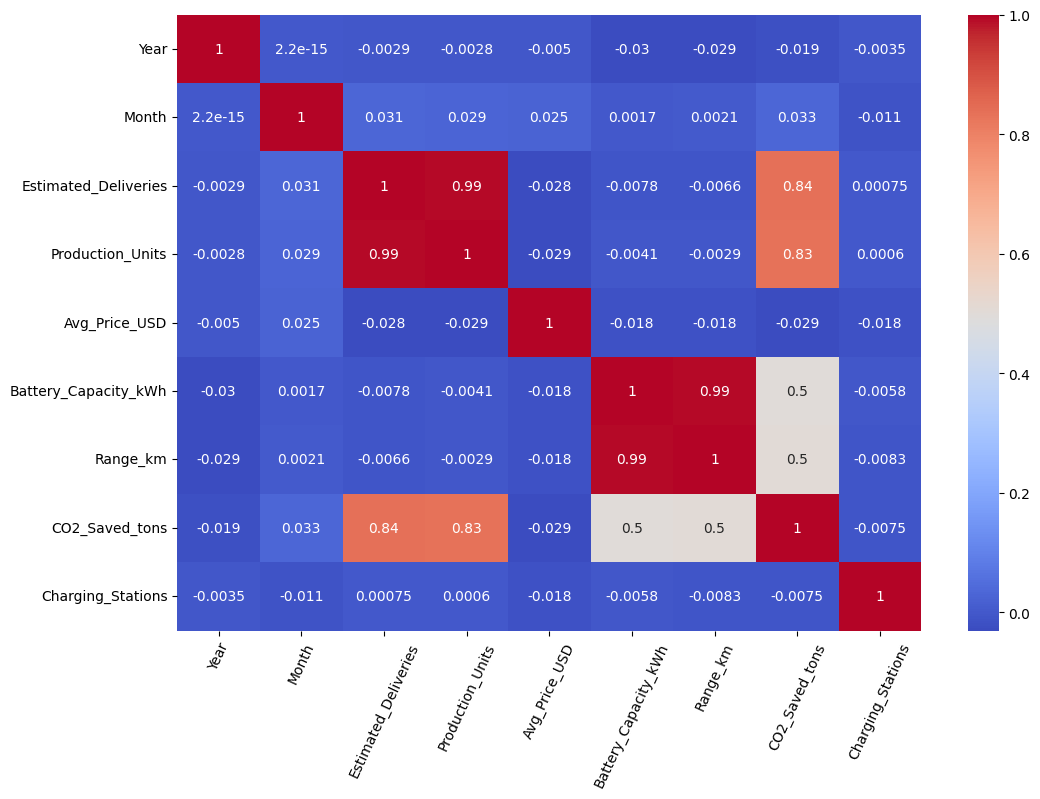

In [17]:
numeric_df = df.select_dtypes(include= np.number)
corr = numeric_df.corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.xticks(rotation=65)
plt.show()

## 7. Feature Engineering

In [18]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

In [19]:
df["Quarter"] = df["Date"].dt.quarter

In [20]:
df["Month_Name"] = df["Date"].dt.month_name()

In [21]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,May
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1,February
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1,January
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,February
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,December


## 8. Label Encoding

In [22]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model']  = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,2,May
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,1,February
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,1,January
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,1,February
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,4,December


In [23]:
X = df.drop(columns = ['Estimated_Deliveries', 'Date', 'Quarter', 'Month_Name'])

y = df["Estimated_Deliveries"]

X.columns

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations'],
      dtype='object')

## 9. Train Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(2112, 11)
(528, 11)


## 10. Building ML Pipeline --> Predictions and Evaluation 

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
def evaluate(name, pipeline, X_tr, X_te, y_tr, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    r2   = r2_score(y_te, preds)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    print(f"{name:25s} | R²: {r2:.4f} | MAE: {mae:,.4f} | RMSE: {rmse:,.4f}")
    return pipeline, preds

pipelines = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge (L2)':        Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (L1)':        Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0, max_iter=5000))]),
}

results = {}
for name, pipe in pipelines.items():
    fitted_pipe, preds = evaluate(name, pipe, X_train, X_test, y_train, y_test)
    results[name] = (fitted_pipe, preds)

Linear Regression         | R²: 0.9901 | MAE: 310.1300 | RMSE: 383.5766
Ridge (L2)                | R²: 0.9901 | MAE: 309.9088 | RMSE: 383.6085
Lasso (L1)                | R²: 0.9902 | MAE: 309.9501 | RMSE: 383.0934


## 11. Cross-Validation

In [27]:
from sklearn.model_selection import GridSearchCV, cross_val_score

lasso_pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=1.0))])

cv_scores = cross_val_score(lasso_pipe, X, y, cv=5, scoring='r2')

print(f"Lasso 5-Fold CV R² (average):          {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores:                          {cv_scores.round(4)}")

Lasso 5-Fold CV R² (average):          0.9903 ± 0.0005
Fold scores:                          [0.9907 0.9904 0.9893 0.9904 0.9908]


## 12. Hyperparameter Tuning

In [28]:
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}

grid_pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso())])

grid = GridSearchCV(grid_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best alpha:  {grid.best_params_['model__alpha']}")
print(f"Best CV R²: {grid.best_score_:.4f}")

tuned_preds = grid.predict(X_test)

score = r2_score(y_test, tuned_preds)
mae = mean_absolute_error(y_test, tuned_preds)
rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))

print(f"\nTuned Lasso on Test Set:")
print(f"  R²:   {score:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")

Best alpha:  1
Best CV R²: 0.9903

Tuned Lasso on Test Set:
  R²:   0.9902
  MAE:  309.9501
  RMSE: 383.0934


## 13. Actual vs Predicted

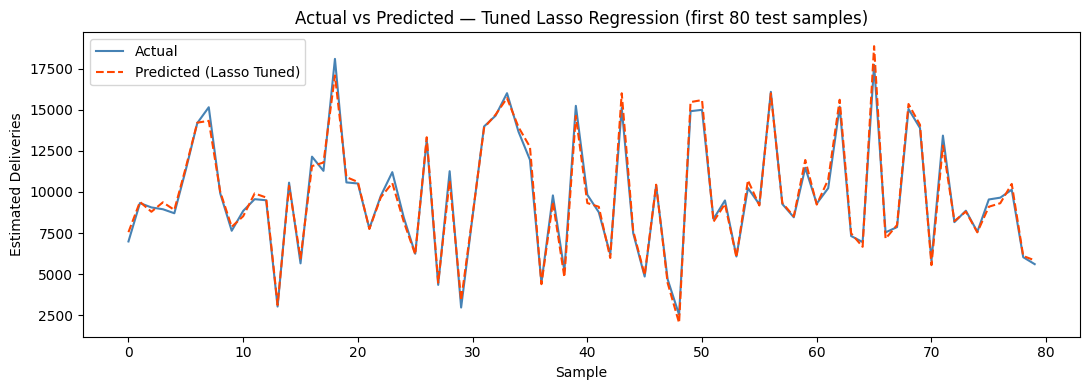

In [29]:
plt.figure(figsize=(11, 4))
plt.plot(y_test.values[:80], label='Actual', color='steelblue', linewidth=1.5)
plt.plot(tuned_preds[:80],   label='Predicted (Lasso Tuned)', color='orangered', linestyle='--', linewidth=1.5)
plt.title('Actual vs Predicted — Tuned Lasso Regression (first 80 test samples)')
plt.xlabel('Sample')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Time series forecasting

In [30]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train = monthly[:-12]
test = monthly[-12:]

model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12)

fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [32]:
forecast = fit.forecast(12)

forecast

2025-01-01    194038.352826
2025-02-01    190503.768497
2025-03-01    197531.545339
2025-04-01    189222.016574
2025-05-01    199540.875268
2025-06-01    191562.898952
2025-07-01    201352.157153
2025-08-01    208162.496422
2025-09-01    198657.202535
2025-10-01    204927.630309
2025-11-01    196218.711682
2025-12-01    206959.341887
Freq: MS, dtype: float64

In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, forecast)

print("Forecast MAE:", mae)

Forecast MAE: 10494.593702709251


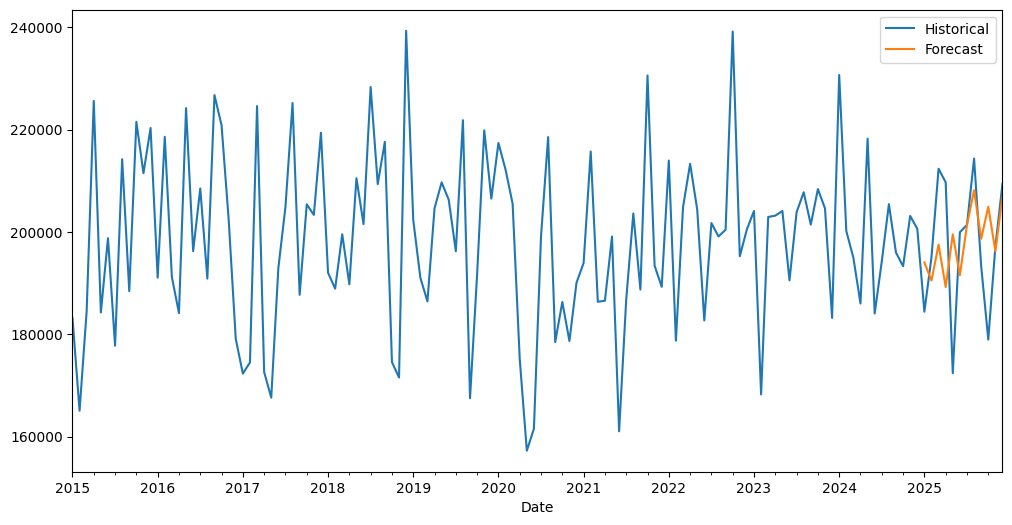

In [34]:
plt.figure(figsize=(12,6))

monthly.plot(
    label="Historical"
)

forecast.plot(
    label="Forecast"
)

plt.legend()

plt.show()

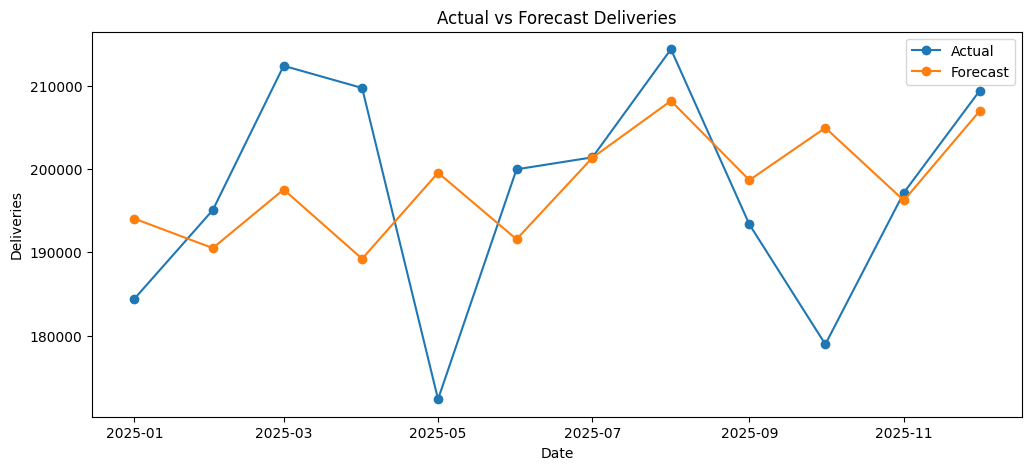

In [35]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test.values,
         label="Actual",
         marker='o')

plt.plot(forecast.index, forecast.values,
         label="Forecast",
         marker='o')

plt.title("Actual vs Forecast Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()

plt.show()

#### Conclusion :
Production_Units and CO2_Saved_tons were the strongest predictors of Tesla deliveries. Lasso Regression with hyperparameter tuning emerged as the best performing regression model with the highest R² score of 0.9902. Additionally, the Holt-Winters Exponential Smoothing model was applied for time series forecasting, achieving a low MAPE (Mean Absolute Percentage Error) of ~5.2%, indicating strong forecasting accuracy.